<a href="https://colab.research.google.com/github/zo-ff/pandas/blob/main/%E3%81%84%E3%81%BE%E3%81%93%E3%82%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

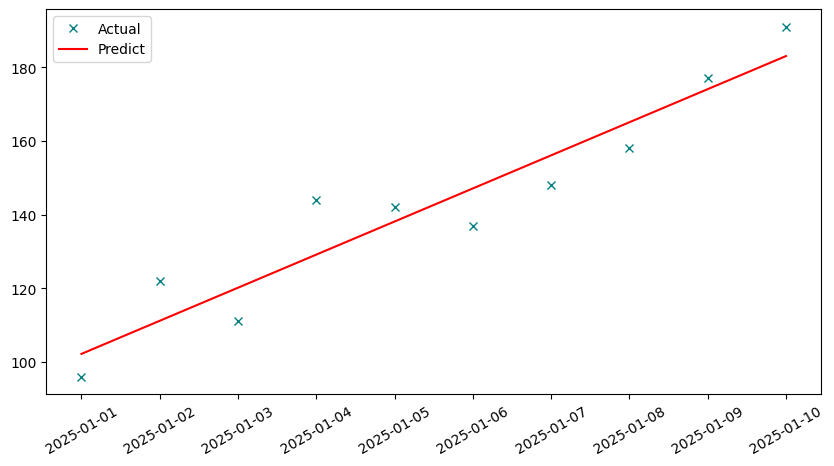

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression

time_dummy=np.arange(1,11,1)

np.random.seed(12)
noise=np.random.randint(-15,15,size=10)
sales=np.arange(100,200,10)+noise
index=pd.date_range(start='2025-01-01',periods=10,freq='D')  #DATE

X=pd.DataFrame(time_dummy,index=index)  #特徴量
y=pd.Series(sales,index=index)  #ターゲット

model=LinearRegression()
model.fit(X,y)
y_pred=model.predict(X)
y_pred_series=pd.Series(y_pred,index=y.index)

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(y,'x',color='teal',label='Actual')
ax.plot(y_pred_series,color='red',label='Predict')
ax.legend()
ax.tick_params(axis='x',rotation=30)

<Axes: >

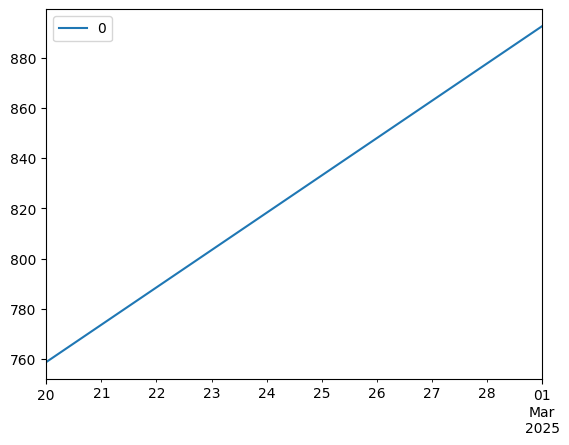

In [ ]:
import pandas as pd
from statsmodels.tsa.deterministic import DeterministicProcess
import numpy as np
from sklearn.linear_model import LinearRegression

yy=np.random.randint(100,1000,50)
y=pd.Series(yy)  #売り上げシリーズ

index=pd.date_range(start='2025-01-01',periods=50,freq='D')  #時系列インデックス
dp=DeterministicProcess(index=index,constant=False,order=1)
XX=dp.in_sample()
X=dp.out_of_sample(steps=10)

model=LinearRegression(fit_intercept=False)
model.fit(XX,y)
z=model.predict(X)
zz=pd.DataFrame(z,index=X.index)
zz.plot()

/tmp/ipykernel_2426/2499656987.py:15: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start="2026-01-01", periods=n_steps, freq="H")


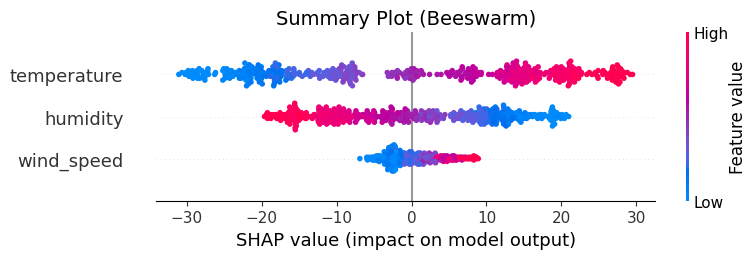

<Figure size 800x500 with 0 Axes>

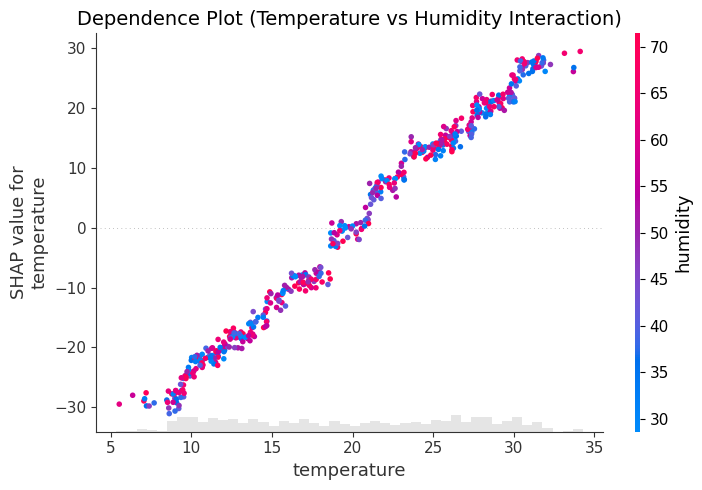

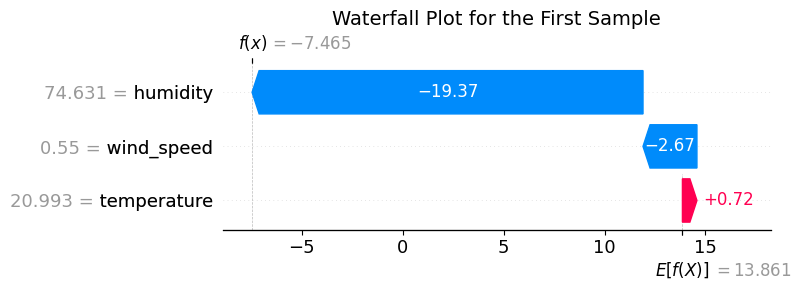

In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

# グラフの日本語文字化け防止（必要に応じて設定してください）
plt.rcParams['font.family'] = 'DejaVu Sans'

# 1. 時系列インデックスと3つの特徴量を持つ模擬データの作成
np.random.seed(42)
n_steps = 500

# 日時のインデックスを作成
time_index = pd.date_range(start="2026-01-01", periods=n_steps, freq="H")

# 3つの特徴量を生成
temp = 20 + 10 * np.sin(np.linspace(0, 8 * np.pi, n_steps)) + np.random.normal(0, 2, n_steps)  # 気温 (周期性あり)
humidity = 50 + 20 * np.cos(np.linspace(0, 4 * np.pi, n_steps)) + np.random.normal(0, 5, n_steps)  # 湿度 (周期性あり)
wind_speed = np.random.exponential(scale=3, size=n_steps)  # 風速 (指数分布)

X = pd.DataFrame({
    'temperature': temp,
    'humidity': humidity,
    'wind_speed': wind_speed
}, index=time_index)

# 目的変数の作成 (特徴量の組み合わせにノイズを加える)
# 気温が高く、湿度が低いとターゲット（例: エアコン需要）が上がると仮定
y = 2.5 * X['temperature'] - 0.8 * X['humidity'] + 1.2 * X['wind_speed'] + np.random.normal(0, 5, n_steps)

# 2. モデルの学習 (LightGBM)
model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model.fit(X, y)

# 3. SHAP値の計算
# TreeExplainerはLightGBMやXGBoostなどの木モデルに高速・正確に対応しています
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# --- 4. グラフの描画 ---

# グラフ 1: Summary Plot (Beeswarm)
# 特徴量が予測全体に与える影響度を一覧できます。
# （縦軸に特徴量、横軸にSHAP値。色が特徴量の値の大小を示します）
plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_values, show=False)
plt.title("Summary Plot (Beeswarm)", fontsize=14)
plt.tight_layout()
plt.show()

# グラフ 2: Dependence Plot (依存関係プロット)
# 特定の特徴量（例: temperature）の値の変化が、予測値にどう影響するか（非線形な関係など）をプロットします。
# temperature（気温）のグラフを、humidity（湿度）の大小で色分けする
plt.figure(figsize=(8, 5))
shap.plots.scatter(
    shap_values[:, "temperature"],
    color=shap_values[:, "humidity"],  # ← ここで「湿度の大小で色分け」を指定します！
    show=False
)
plt.title("Dependence Plot (Temperature vs Humidity Interaction)", fontsize=14)
plt.tight_layout()
plt.show()

# グラフ 3: Waterfall Plot (個別のデータ点の要因分析)
# 特定の1つの予測（ここではインデックス0のデータ）に対して、どの特徴量がどれだけ予測値を押し上げたか/下げたかを可視化します。
plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_values[0], show=False)
plt.title("Waterfall Plot for the First Sample", fontsize=14)
plt.tight_layout()
plt.show()